# RQ1 — visual exploration of all analysis tables

Loads every CSV produced by `make_headline_figures.py` and gives an interactive/iterable version of the same figures, plus a couple extra views. Run cells top to bottom; each section is independent so missing files (e.g. `main_effects_interaction_table.csv` before model3 is pooled) just print a message instead of breaking the notebook.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ANALYSIS = Path.cwd() if Path.cwd().name == "analysis" else Path.cwd() / "analysis"
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

## Master comparison table
One row per pooled model/arm — miss rate at the lowest tested U, U_safe at p99/p999, and the p99 collapse ratio vs model1.

,model,scale,U_min_tested,miss_rate_at_U_min,U_safe_p99,U_safe_p999,U_safe_p99_vs_model1
0,model1_pooled,soft,0.1,0.00065,0.9400,0.5958,1.000000
1,model1_pooled,tight,0.1,0.00015,0.9400,0.2995,1.000000
2,model2_pooled,soft,0.1,0.09780,0.1000,0.1000,0.106383
3,model2_pooled,tight,0.1,0.00060,0.1964,0.1956,0.208936


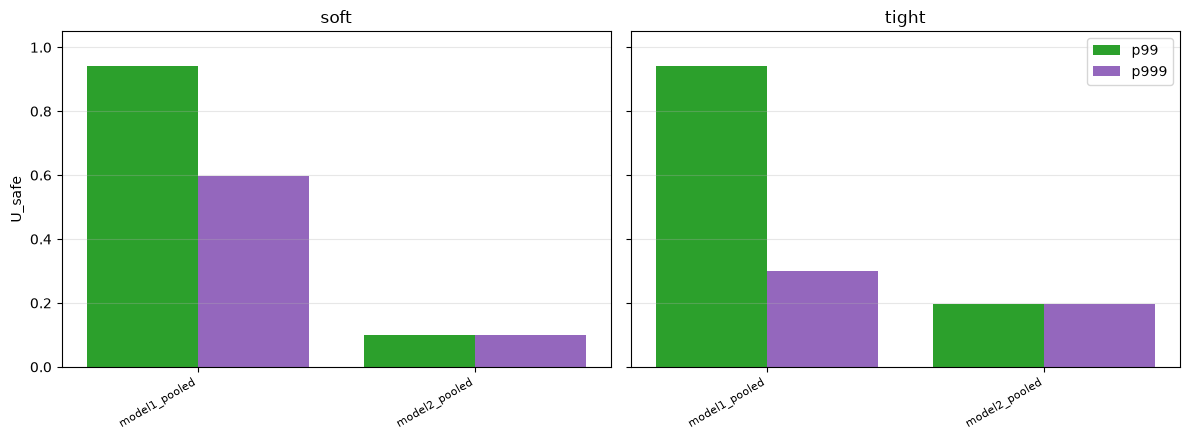

In [2]:
master = pd.read_csv(ANALYSIS / "master_comparison_table.csv")
display(master)

fig, axes = plt.subplots(1, master["scale"].nunique(), figsize=(6 * master["scale"].nunique(), 4.5), sharey=True)
if master["scale"].nunique() == 1:
    axes = [axes]
for ax, scale in zip(axes, sorted(master["scale"].unique())):
    sub = master[master.scale == scale]
    x = range(len(sub))
    ax.bar([i - 0.2 for i in x], sub["U_safe_p99"], width=0.4, label="p99", color="#2ca02c")
    ax.bar([i + 0.2 for i in x], sub["U_safe_p999"], width=0.4, label="p999", color="#9467bd")
    ax.set_xticks(list(x)); ax.set_xticklabels(sub["model"], rotation=30, ha="right", fontsize=8)
    ax.set_title(scale); ax.set_ylim(0, 1.05); ax.grid(axis="y", alpha=0.3)
axes[0].set_ylabel("U_safe"); axes[-1].legend()
fig.tight_layout()

## Provisioning detail — every pooled model side by side

In [3]:
prov_rows = []
for d in sorted(ANALYSIS.glob("*_pooled")):
    p = d / "provisioning_table.csv"
    if p.exists():
        df = pd.read_csv(p)
        prov_rows.append(df)
prov_all = pd.concat(prov_rows, ignore_index=True) if prov_rows else pd.DataFrame()
display(prov_all.sort_values(["scale", "confidence", "U_safe"]))

,model,scale,confidence,U_safe,note,U_tested_max,margin_needed_at_U_tested_max
4,model2_pooled,soft,p99,0.1000,breaks even at lowest tested U,0.50,1.017
0,model1_pooled,soft,p99,0.9400,safe across full tested range,0.94,0.710
5,model2_pooled,soft,p999,0.1000,breaks even at lowest tested U,0.50,1.019
1,model1_pooled,soft,p999,0.5958,interpolated crossing,0.94,0.800
6,model2_pooled,tight,p99,0.1964,interpolated crossing,0.50,0.478
2,model1_pooled,tight,p99,0.9400,safe across full tested range,0.94,0.699
7,model2_pooled,tight,p999,0.1956,interpolated crossing,0.50,1.025
3,model1_pooled,tight,p999,0.2995,interpolated crossing,0.94,0.707


## Miss rate vs utilization — every pooled model overlaid

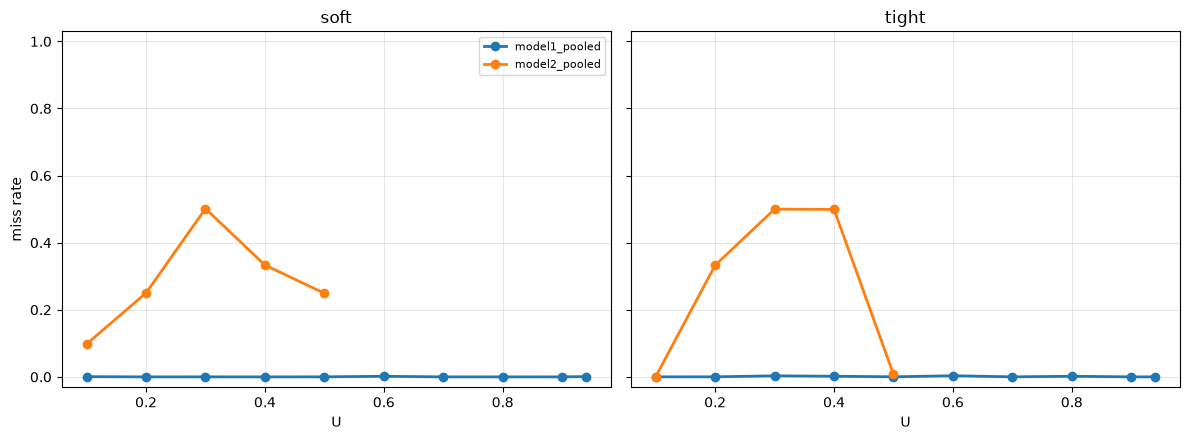

In [4]:
summ_rows = []
for d in sorted(ANALYSIS.glob("*_pooled")):
    p = d / "summary.csv"
    if p.exists():
        summ_rows.append(pd.read_csv(p))
summ_all = pd.concat(summ_rows, ignore_index=True) if summ_rows else pd.DataFrame()

if not summ_all.empty:
    scales = sorted(summ_all["scale"].unique())
    fig, axes = plt.subplots(1, len(scales), figsize=(6 * len(scales), 4.5), sharey=True)
    if len(scales) == 1:
        axes = [axes]
    for ax, scale in zip(axes, scales):
        for model, g in summ_all[summ_all.scale == scale].groupby("model"):
            g = g.sort_values("U")
            ax.plot(g["U"], g["miss_rate"], marker="o", label=model, lw=2)
        ax.set_title(scale); ax.set_xlabel("U"); ax.set_ylim(-0.03, 1.03); ax.grid(alpha=0.3)
    axes[0].set_ylabel("miss rate"); axes[0].legend(fontsize=8)
    fig.tight_layout()

## Budget overrun — observed C vs calibrated-expected C vs Q
`inflation_vs_calibrated` > 1 means the task took longer than its isolated calibration target; once `observed_C_p50_us` exceeds `Q_budget_us` (`exceeds_budget=True`), a miss is structurally guaranteed every period.

,label,scale,U,Q_budget_us,expected_C_us,observed_C_p50_us,inflation_vs_calibrated,pct_over_budget,exceeds_budget
0,model1,tight,0.10,1000.0,700.0,745.9590,1.065656,-25.404100,False
1,model1,tight,0.20,2000.0,1400.0,1492.3880,1.065991,-25.380600,False
2,model1,tight,0.30,3000.0,2100.0,2248.6535,1.070787,-25.044883,False
3,model1,tight,0.40,4000.0,2800.0,2867.8265,1.024224,-28.304337,False
4,model1,tight,0.50,5000.0,3500.0,3650.3880,1.042968,-26.992240,False
5,model1,tight,0.60,6000.0,4200.0,4454.8860,1.060687,-25.751900,False
6,model1,tight,0.70,7000.0,4900.0,5265.8815,1.074670,-24.773121,False
7,model1,tight,0.80,8000.0,5600.0,6034.5015,1.077590,-24.568731,False
8,model1,tight,0.90,9000.0,6300.0,6549.6815,1.039632,-27.225761,False
9,model1,tight,0.94,9400.0,6580.0,6845.6825,1.040377,-27.173590,False


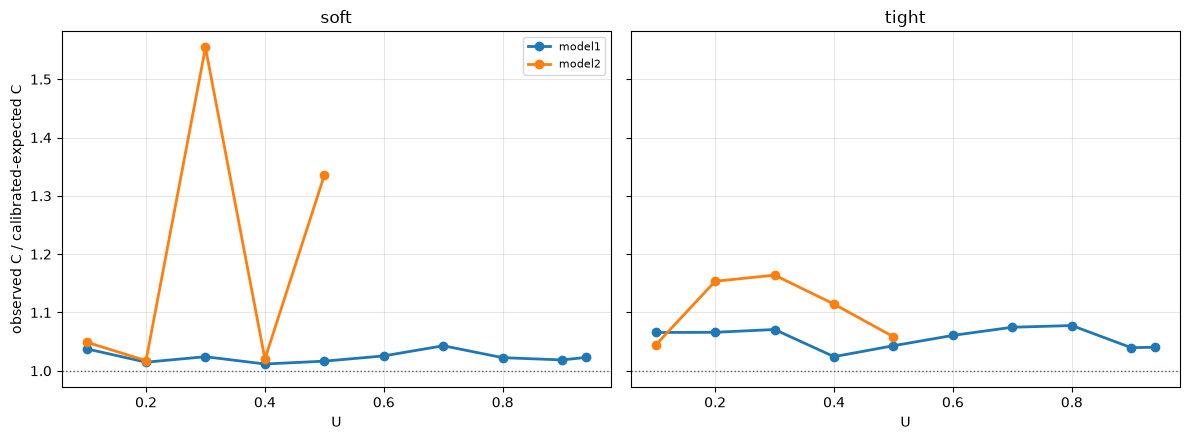

In [5]:
bo_path = ANALYSIS / "budget_overrun_table.csv"
if bo_path.exists():
    bo = pd.read_csv(bo_path)
    display(bo)

    scales = sorted(bo["scale"].unique())
    fig, axes = plt.subplots(1, len(scales), figsize=(6 * len(scales), 4.5), sharey=True)
    if len(scales) == 1:
        axes = [axes]
    for ax, scale in zip(axes, scales):
        for label, g in bo[bo.scale == scale].groupby("label"):
            g = g.sort_values("U")
            ax.plot(g["U"], g["inflation_vs_calibrated"], marker="o", label=label, lw=2)
        ax.axhline(1.0, color="k", ls=":", lw=1, alpha=0.6)
        ax.set_title(scale); ax.set_xlabel("U"); ax.grid(alpha=0.3)
    axes[0].set_ylabel("observed C / calibrated-expected C"); axes[0].legend(fontsize=8)
    fig.tight_layout()
else:
    print(f"{bo_path} not found -- run make_headline_figures.py first")

## Job-level mechanism attribution
Mean `dispatch_latency_us` / `mid_job_preempt_us` / `nonvol_ctxt` per condition — distinguishes dispatch-delay-dominated from preemption-dominated from execution-inflation-dominated degradation.

,label,scale,U,n,mean_C_cputime_us,mean_dispatch_latency_us,mean_mid_job_preempt_us,mean_nonvol_ctxt
0,model1,soft,0.10,20000,7256.484904,104.525063,59.711859,0.000650
1,model1,soft,0.20,20000,14204.974121,19.797171,1.730154,0.006250
2,model1,soft,0.30,20000,21458.890006,27.801087,8.596444,0.000100
3,model1,soft,0.40,20000,28235.015767,111.878410,1.856360,0.000000
4,model1,soft,0.50,20000,35658.667545,90.325023,9.057332,0.000150
5,model1,soft,0.60,20000,43141.958986,29.995814,69.082450,0.001700
6,model1,soft,0.70,20000,50755.855850,74.985680,0.990173,0.000050
7,model1,soft,0.80,20000,57169.469145,88.862785,0.879494,0.000000
8,model1,soft,0.90,20000,63728.468937,17.880137,0.034940,0.012500
9,model1,soft,0.94,20000,67064.325355,24.799374,4.800836,0.000850


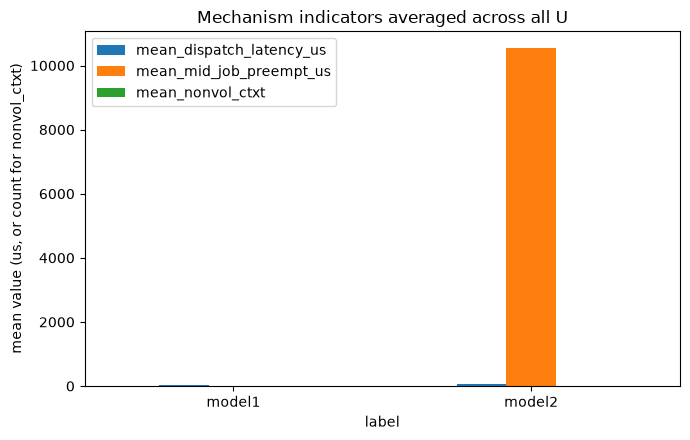

In [6]:
jm_path = ANALYSIS / "job_level_mechanism_table.csv"
if jm_path.exists():
    jm = pd.read_csv(jm_path)
    display(jm)

    metric_cols = [c for c in jm.columns if c.startswith("mean_") and c != "mean_C_cputime_us"]
    agg = jm.groupby("label")[metric_cols].mean()
    ax = agg.plot(kind="bar", figsize=(7, 4.5))
    ax.set_ylabel("mean value (us, or count for nonvol_ctxt)")
    ax.set_title("Mechanism indicators averaged across all U")
    plt.xticks(rotation=0)
    plt.tight_layout()
else:
    print(f"{jm_path} not found -- run make_headline_figures.py first")

## Claim 2 — main effects & interaction (model3's 2x2 factorial)
Only populated once model3's four arms (sib_cfs, sib_res, phys_cfs, phys_res) are pooled and `main_effects_interaction_table()` has been called with the real directory names in `make_headline_figures.py`.

In [7]:
me_path = ANALYSIS / "main_effects_interaction_table.csv"
if me_path.exists():
    me = pd.read_csv(me_path)
    display(me)

    effect_cols = ["PAIR_TYPE_effect_unreserved_competitor", "PAIR_TYPE_effect_reserved_competitor",
                   "COMPETITOR_TYPE_effect_sibling", "COMPETITOR_TYPE_effect_physical", "interaction"]
    ax = me.set_index("scale")[effect_cols].plot(kind="bar", figsize=(8, 4.5))
    ax.set_ylabel("miss-rate delta")
    ax.axhline(0, color="k", lw=1)
    ax.set_title("Claim2: main effects and interaction")
    plt.xticks(rotation=0)
    plt.tight_layout()
else:
    print(f"{me_path} not found yet -- pool model3's 4 arms and uncomment "
          "main_effects_interaction_table(...) in make_headline_figures.py first")

/home/silvia/Documents/GraduationProject/research-questions/RQ1_new/analysis/main_effects_interaction_table.csv not found yet -- pool model3's 4 arms and uncomment main_effects_interaction_table(...) in make_headline_figures.py first


## Round-to-round stability (not pooled)
Do independent sessions agree with each other? Validates the pooling decision -- not a time-of-day study, just enough rounds to check sessions broadly agree.

=== model1 ===


,round,round_time,scale,U,n,median_C,cv,miss_rate
0,round1,2026-08-03 09:09:35.786400,soft,0.10,5000,7434.4300,0.034461,0.0026
1,round1,2026-08-03 09:09:35.786400,soft,0.20,5000,14446.4250,0.004099,0.0000
2,round1,2026-08-03 09:09:35.786400,soft,0.30,5000,21684.3765,0.004433,0.0000
3,round1,2026-08-03 09:09:35.786400,soft,0.40,5000,28625.6135,0.006311,0.0000
4,round1,2026-08-03 09:09:35.786400,soft,0.50,5000,36662.0490,0.025560,0.0006
5,round1,2026-08-03 09:09:35.786400,soft,0.60,5000,43235.0700,0.003136,0.0000
6,round1,2026-08-03 09:09:35.786400,soft,0.70,5000,51227.5170,0.002883,0.0002
7,round1,2026-08-03 09:09:35.786400,soft,0.80,5000,58551.3980,0.027093,0.0000
8,round1,2026-08-03 09:09:35.786400,soft,0.90,5000,64414.4070,0.002799,0.0000
9,round1,2026-08-03 09:09:35.786400,soft,0.94,5000,67372.6380,0.002351,0.0000


=== model2 ===


,round,round_time,scale,U,n,median_C,cv,miss_rate
0,round1,2026-08-03 09:09:35.944397,soft,0.1,5000,9718.7715,0.032128,0.3910
1,round1,2026-08-03 09:09:35.944397,soft,0.2,5000,14255.9130,0.008342,0.0000
2,round1,2026-08-03 09:09:35.944397,soft,0.3,5000,33137.4400,0.006235,1.0000
3,round1,2026-08-03 09:09:35.944397,soft,0.4,5000,28116.5360,0.005405,0.0000
4,round1,2026-08-03 09:09:35.944397,soft,0.5,5000,46081.8160,0.021241,0.0000
5,round1,2026-08-03 09:09:35.944397,tight,0.1,5000,732.6540,0.019764,0.0002
6,round1,2026-08-03 09:09:35.944397,tight,0.2,5000,1543.5875,0.024440,0.0004
7,round1,2026-08-03 09:09:35.944397,tight,0.3,5000,2188.5990,0.016242,0.0002
8,round1,2026-08-03 09:09:35.944397,tight,0.4,5000,4135.2540,0.015623,0.9972
9,round1,2026-08-03 09:09:35.944397,tight,0.5,5000,3686.2785,0.015615,0.0002


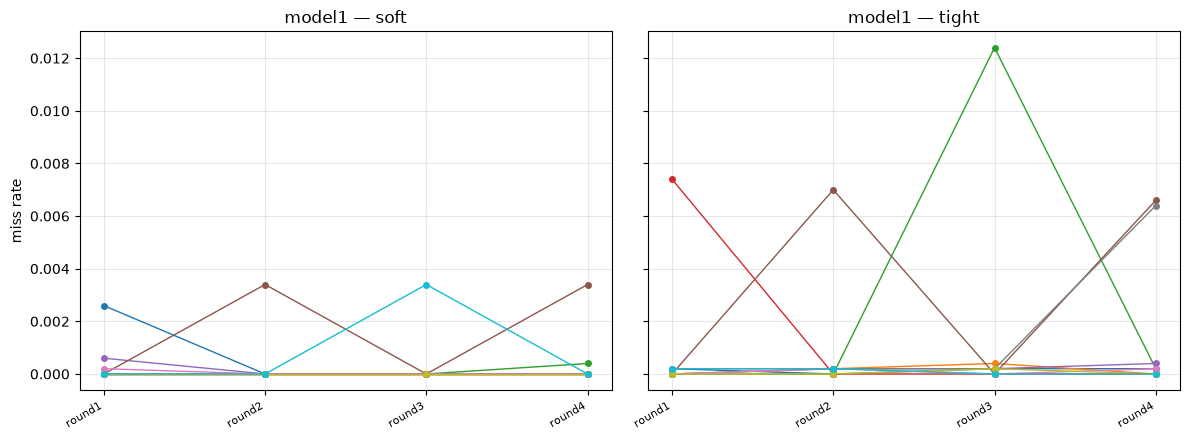

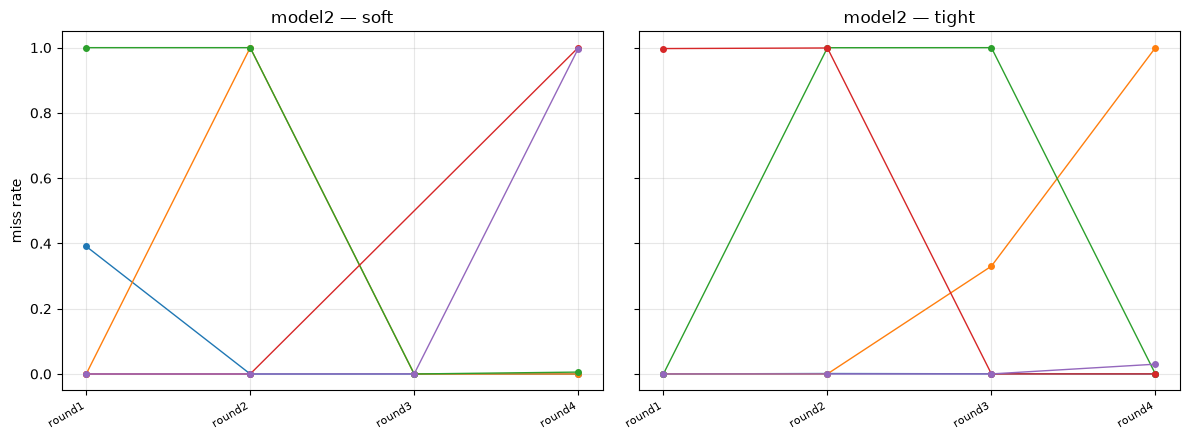

In [8]:
for base_model in ["model1", "model2"]:
    p = ANALYSIS / f"{base_model}_round_stability.csv"
    if not p.exists():
        print(f"{p} not found -- skipping {base_model}")
        continue
    rs = pd.read_csv(p)
    print(f"=== {base_model} ===")
    display(rs.head(20))

    scales = sorted(rs["scale"].unique())
    fig, axes = plt.subplots(1, len(scales), figsize=(6 * len(scales), 4.5), sharey=True)
    if len(scales) == 1:
        axes = [axes]
    for ax, scale in zip(axes, scales):
        sub = rs[rs.scale == scale]
        for u, g in sub.groupby("U"):
            ax.plot(g["round"], g["miss_rate"], marker="o", lw=1, ms=4, label=f"U={u:g}")
        ax.set_title(f"{base_model} — {scale}"); ax.grid(alpha=0.3)
        plt.setp(ax.get_xticklabels(), rotation=30, ha="right", fontsize=8)
    axes[0].set_ylabel("miss rate")
    fig.tight_layout()